## The Curse of Dimensionality Code File

### Lorensius Jose Veron Jumadi

References: https://www.nature.com/articles/s41592-018-0019-x

Created with the help of ChatGPT

In [13]:
## Dependencies
import numpy as np
import matplotlib.pyplot as plt

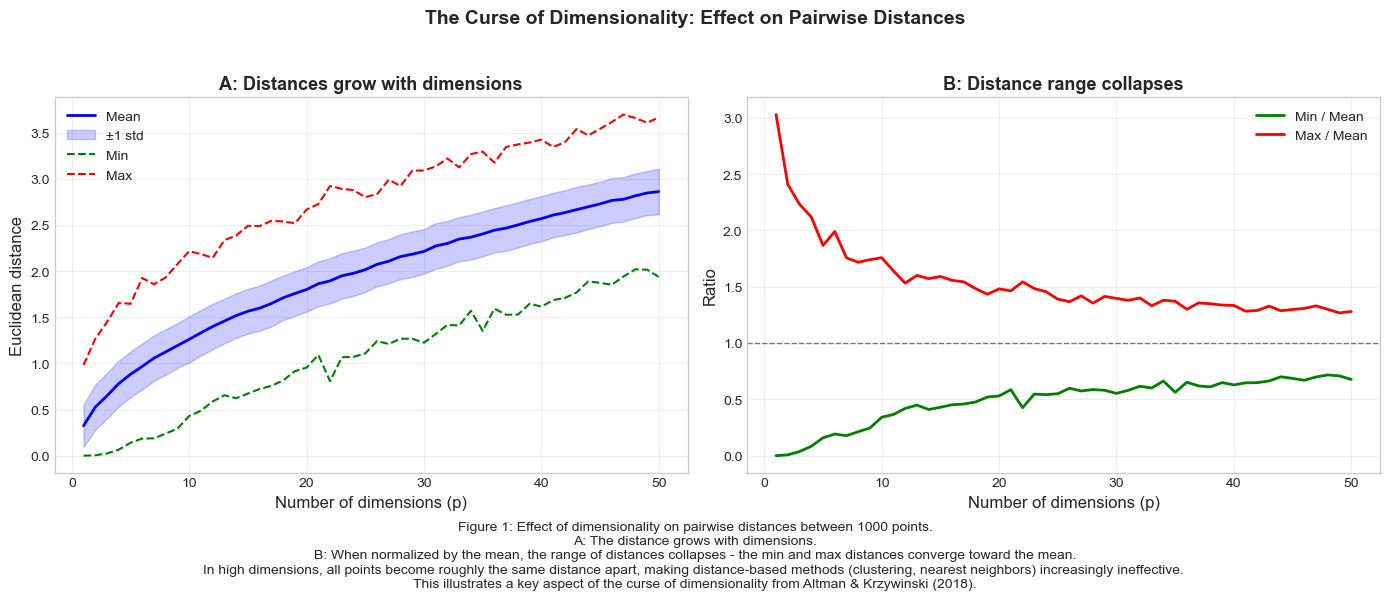

In [18]:
n_points = 1000
max_dim = 50
dimensions = range(1, max_dim + 1)
n_pairs = 5000  

mean_dist = []
std_dist = []
min_dist = []
max_dist = []

for dim in dimensions:
    # Generate random points in [0, 1]^dim
    points = np.random.rand(n_points, dim)
    
    # Sample random pairs
    distances = []
    for _ in range(n_pairs):
        i, j = np.random.choice(n_points, 2, replace=False)
        dist = np.sqrt(np.sum((points[i] - points[j])**2))
        distances.append(dist)
    
    mean_dist.append(np.mean(distances))
    std_dist.append(np.std(distances))
    min_dist.append(np.min(distances))
    max_dist.append(np.max(distances))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plt.subplots_adjust(bottom=0.25)

ax1.plot(dimensions, mean_dist, 'b-', linewidth=2, label='Mean')
ax1.fill_between(dimensions, 
                  np.array(mean_dist) - np.array(std_dist),
                  np.array(mean_dist) + np.array(std_dist),
                  alpha=0.2, color='blue', label='±1 std')
ax1.plot(dimensions, min_dist, 'g--', linewidth=1.5, label='Min')
ax1.plot(dimensions, max_dist, 'r--', linewidth=1.5, label='Max')

ax1.set_xlabel('Number of dimensions (p)', fontsize=12)
ax1.set_ylabel('Euclidean distance', fontsize=12)
ax1.set_title('A: Distances grow with dimensions', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

min_ratio = np.array(min_dist) / np.array(mean_dist)
max_ratio = np.array(max_dist) / np.array(mean_dist)

ax2.plot(dimensions, min_ratio, 'g-', linewidth=2, label='Min / Mean')
ax2.plot(dimensions, max_ratio, 'r-', linewidth=2, label='Max / Mean')
ax2.axhline(y=1, color='k', linestyle='--', linewidth=1, alpha=0.5)

ax2.set_xlabel('Number of dimensions (p)', fontsize=12)
ax2.set_ylabel('Ratio', fontsize=12)
ax2.set_title('B: Distance range collapses', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('The Curse of Dimensionality: Effect on Pairwise Distances', 
             fontsize=14, fontweight='bold', y=0.98)

caption = ("Figure 1: Effect of dimensionality on pairwise distances between 1000 points.\n"
           "A: The distance grows with dimensions.\n" 
           "B: When normalized by the mean, the range of distances collapses - the min and max distances converge toward the mean.\n"
           "In high dimensions, all points become roughly the same distance apart, making distance-based methods (clustering, nearest neighbors) increasingly ineffective. \n"
           "This illustrates a key aspect of the curse of dimensionality from Altman & Krzywinski (2018).")

plt.figtext(0.5, 0.02, caption, wrap=True, horizontalalignment='center', 
            fontsize=10)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.savefig('Jose_CoD_Figure.png', dpi=300, bbox_inches='tight')
plt.show()
